In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("laptop_price - dataset.csv")

In [3]:
display(df.head())
print(df.shape)
print(df.columns)
print(df.info())

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


(1275, 15)
Index(['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution',
       'CPU_Company', 'CPU_Type', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Memory',
       'GPU_Company', 'GPU_Type', 'OpSys', 'Weight (kg)', 'Price (Euro)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1275 non-null   object 
 1   Product              1275 non-null   object 
 2   TypeName             1275 non-null   object 
 3   Inches               1275 non-null   float64
 4   ScreenResolution     1275 non-null   object 
 5   CPU_Company          1275 non-null   object 
 6   CPU_Type             1275 non-null   object 
 7   CPU_Frequency (GHz)  1275 non-null   float64
 8   RAM (GB)             1275 non-null   int64  
 9   Memory               1275 non-null   object 
 10  GPU_Company          1275 non-

In [4]:
df.isnull().sum()

Company                0
Product                0
TypeName               0
Inches                 0
ScreenResolution       0
CPU_Company            0
CPU_Type               0
CPU_Frequency (GHz)    0
RAM (GB)               0
Memory                 0
GPU_Company            0
GPU_Type               0
OpSys                  0
Weight (kg)            0
Price (Euro)           0
dtype: int64

In [5]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zero values")

Inches: 0 zero values
CPU_Frequency (GHz): 0 zero values
RAM (GB): 0 zero values
Weight (kg): 0 zero values
Price (Euro): 0 zero values


In [6]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    blank_count = (df[col].str.strip() == "").sum()
    print(f"{col}: {blank_count} blank values")

Company: 0 blank values
Product: 0 blank values
TypeName: 0 blank values
ScreenResolution: 0 blank values
CPU_Company: 0 blank values
CPU_Type: 0 blank values
Memory: 0 blank values
GPU_Company: 0 blank values
GPU_Type: 0 blank values
OpSys: 0 blank values


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.drop_duplicates(inplace=True)

# Fill missing values
for col in df.select_dtypes(include="number").columns:
    df[col].fillna(df[col].mean())

for col in df.select_dtypes(include="object").columns:
    df[col].fillna(df[col].mode()[0])

# Standardize text
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.lower().str.strip()

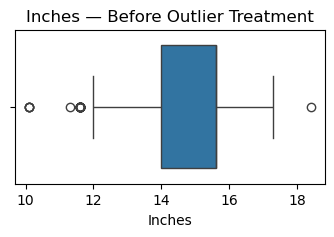

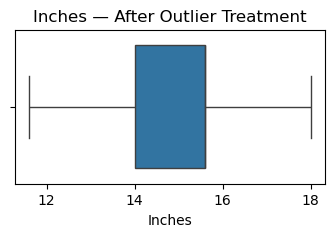

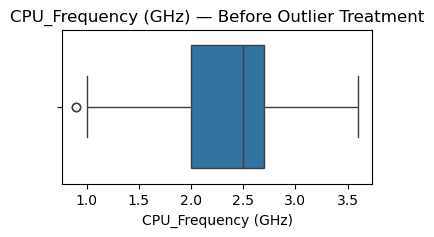

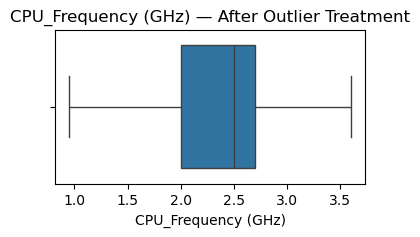

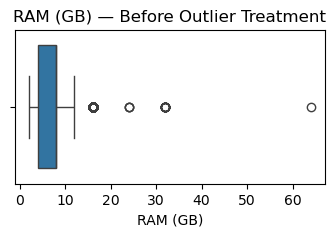

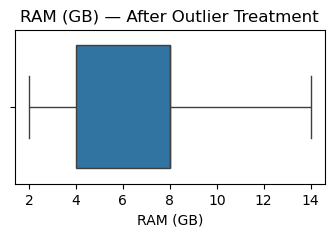

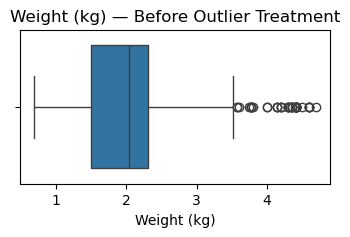

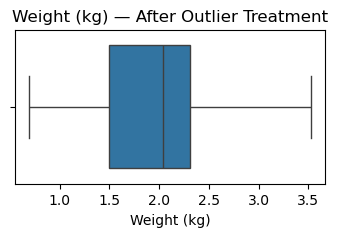

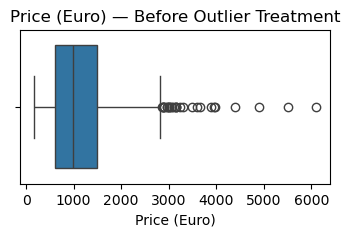

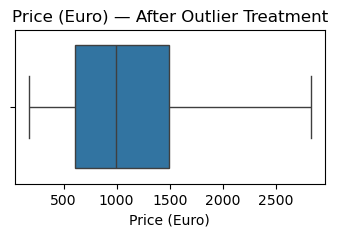

In [9]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:

    plt.figure(figsize=(4, 2))
    sns.boxplot(x=df[col])
    plt.title(f"{col} — Before Outlier Treatment")
    plt.show()

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

    plt.figure(figsize=(4, 2))
    sns.boxplot(x=df[col])
    plt.title(f"{col} — After Outlier Treatment")
    plt.show()

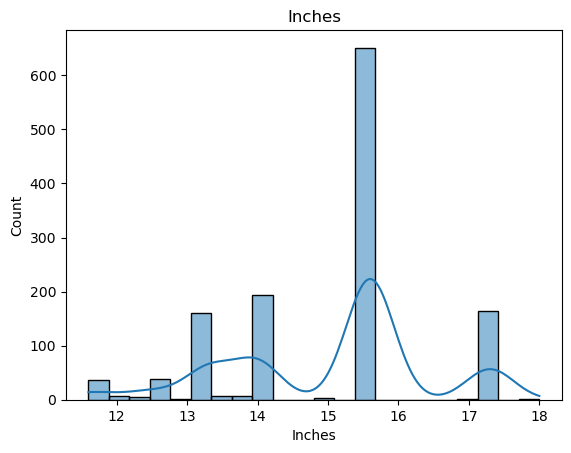

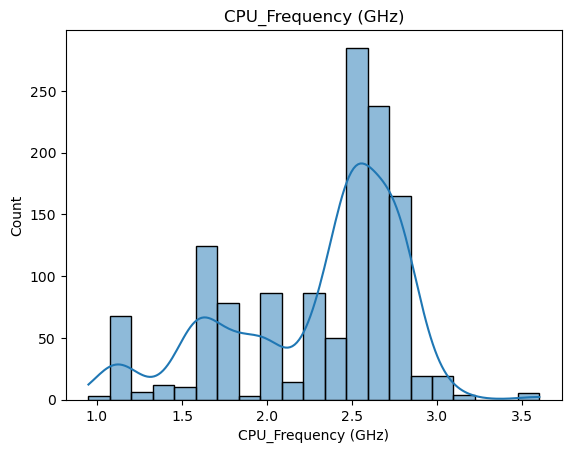

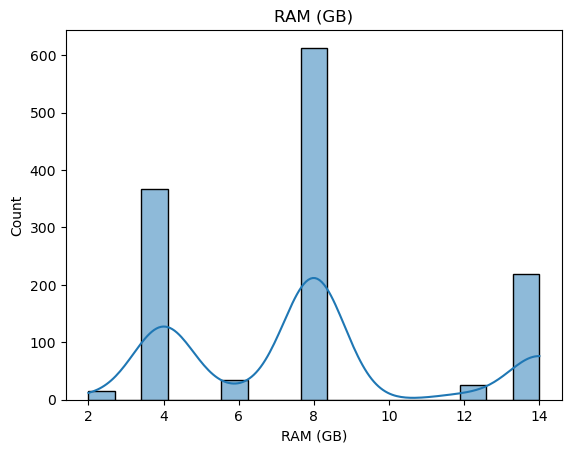

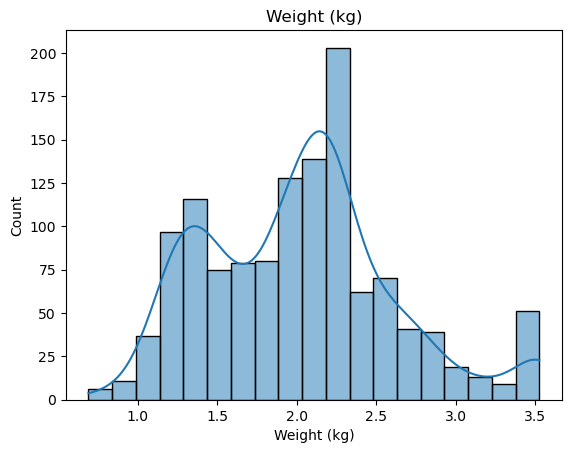

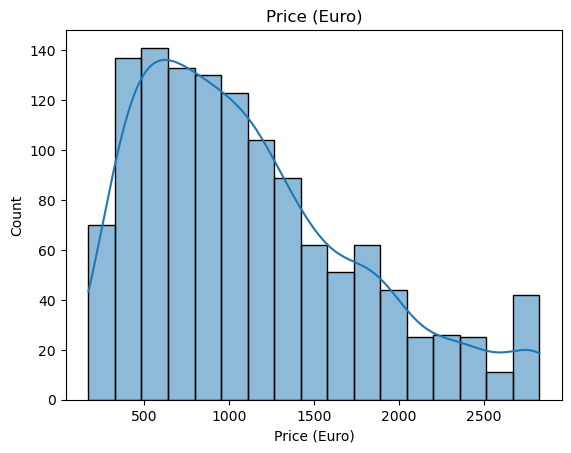

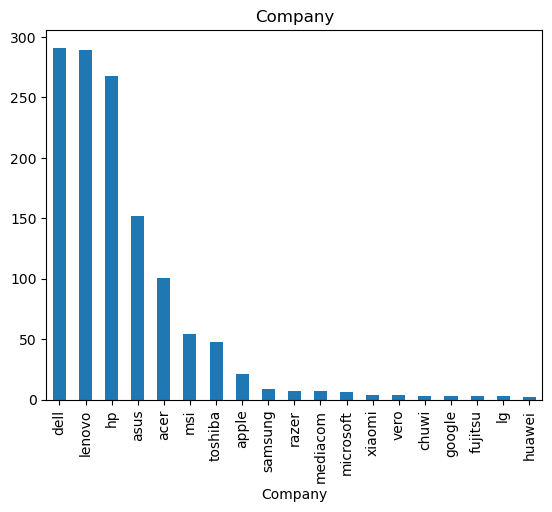

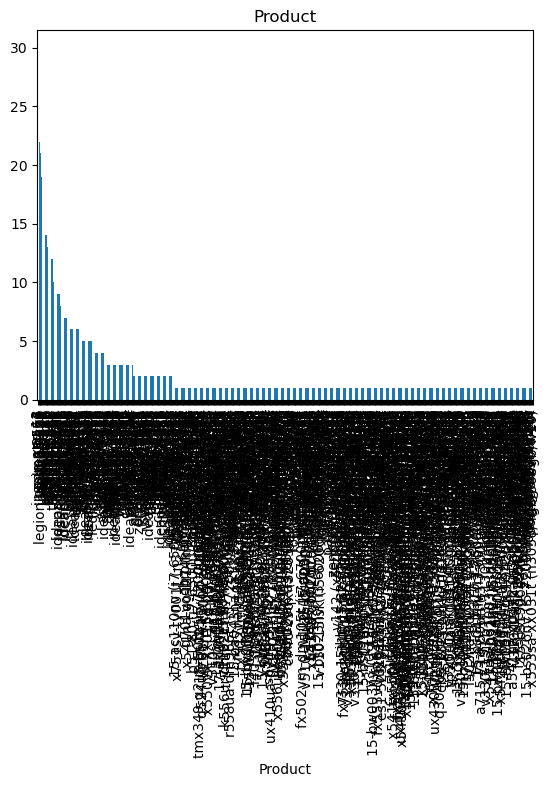

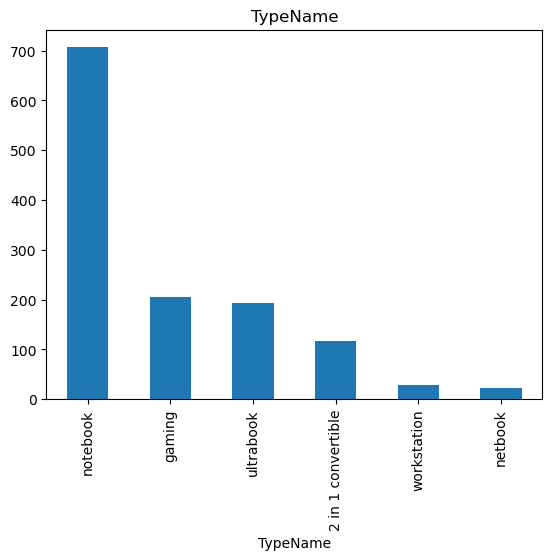

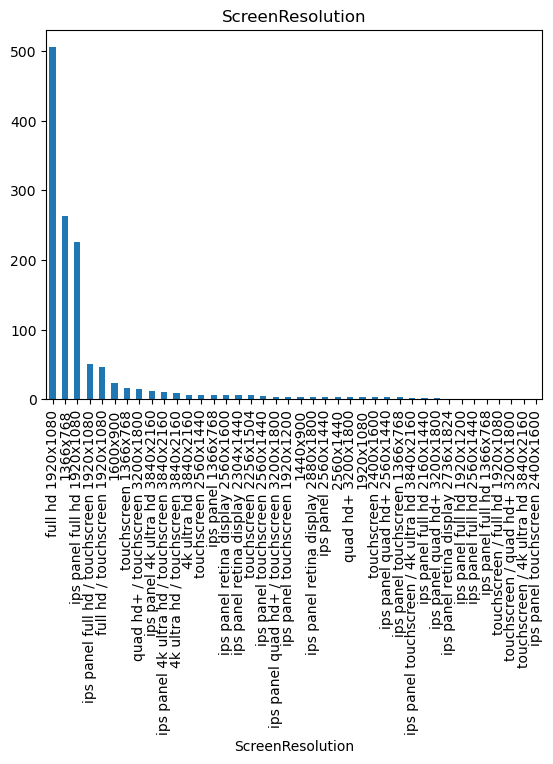

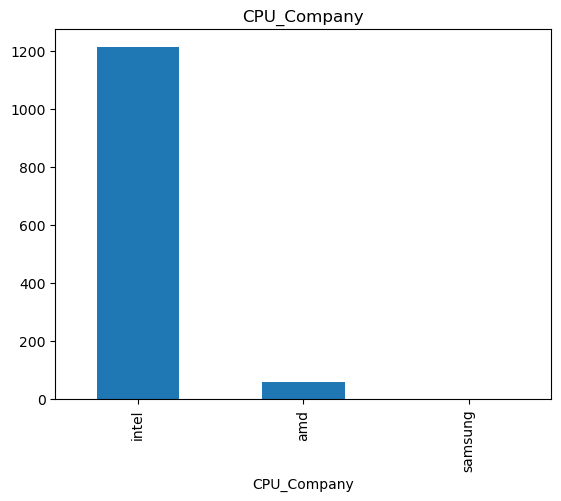

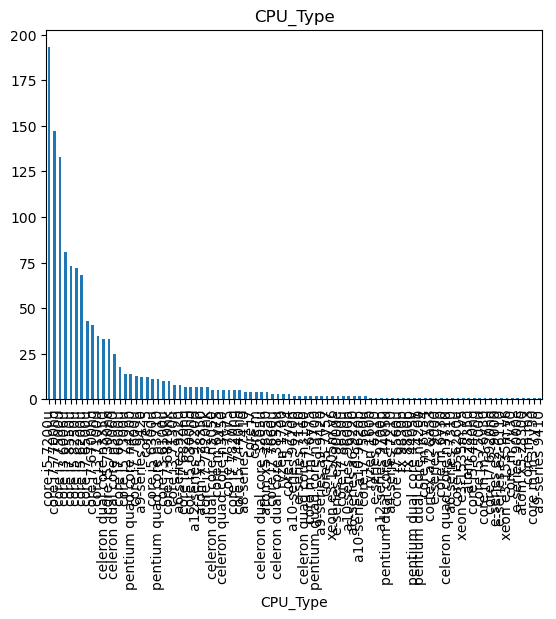

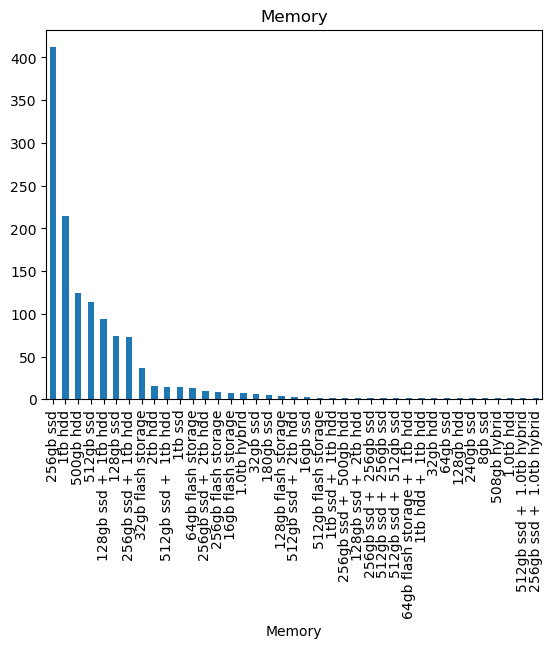

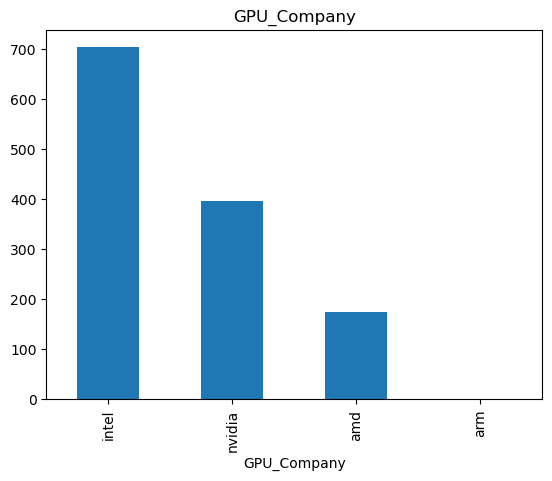

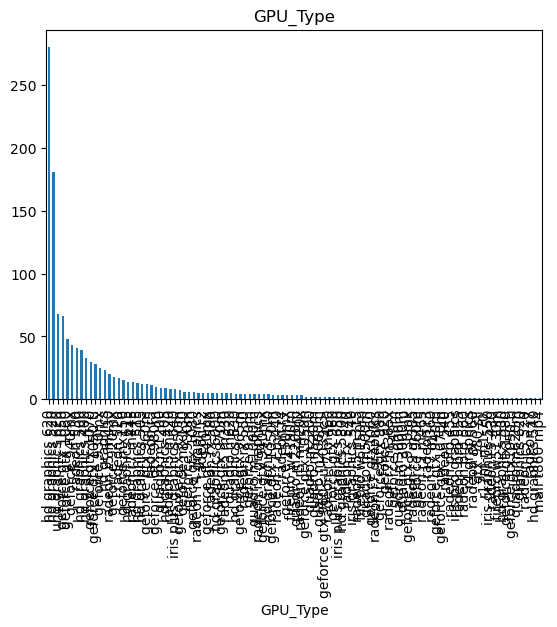

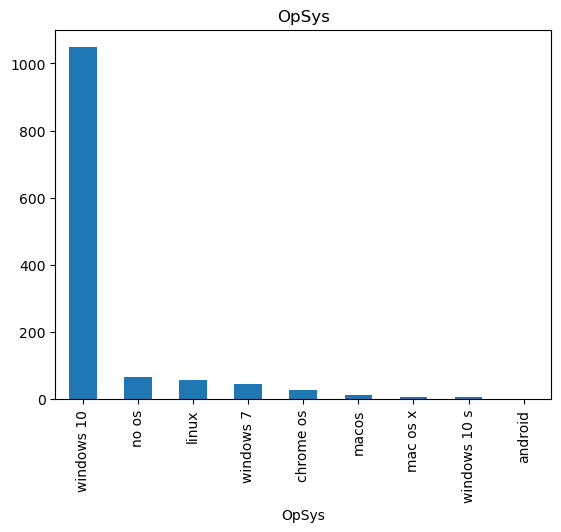

In [10]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

for col in cat_cols:
    df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.show()

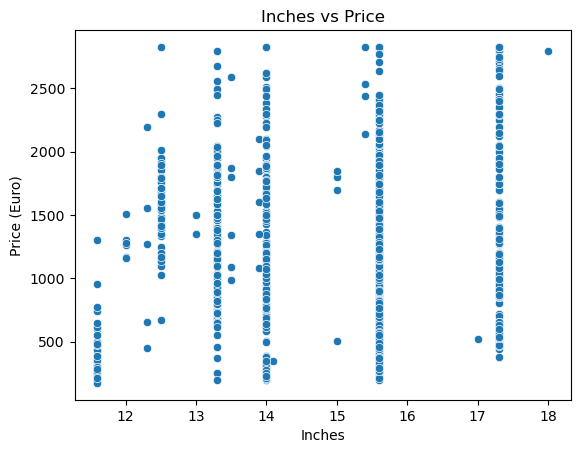

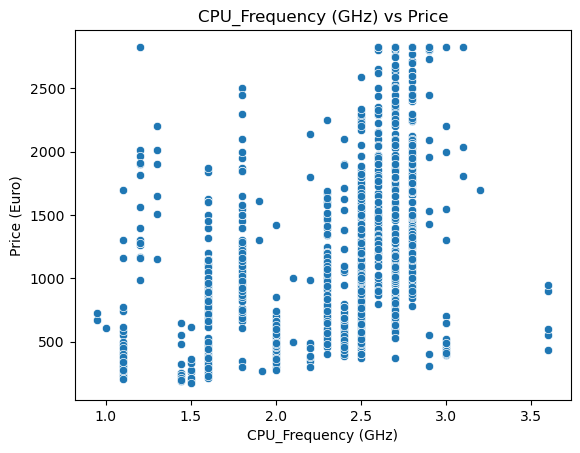

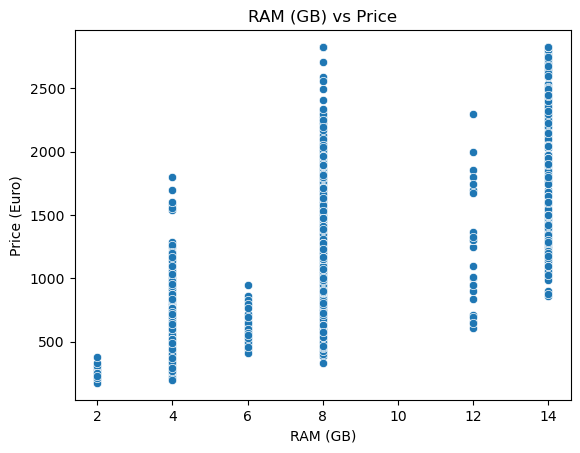

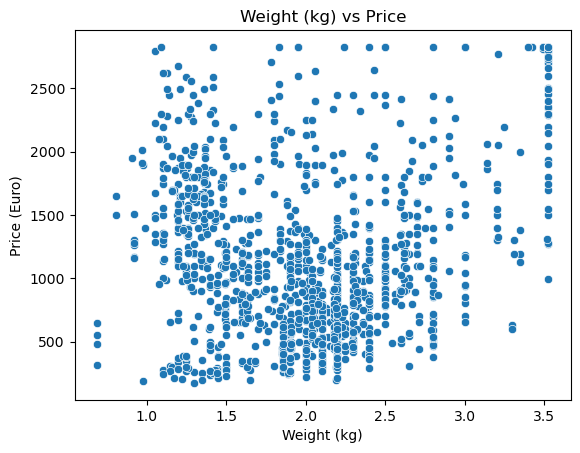

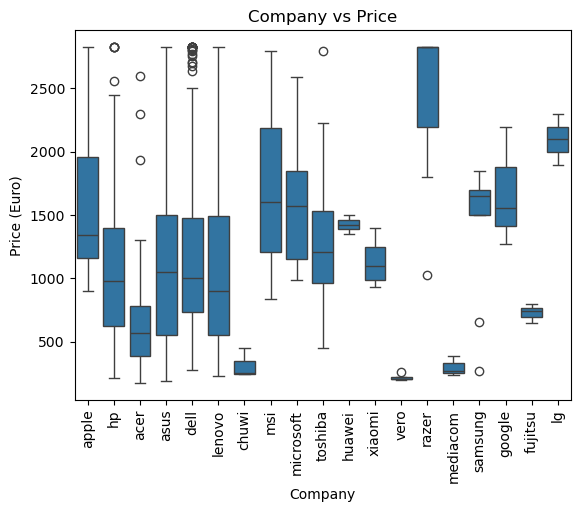

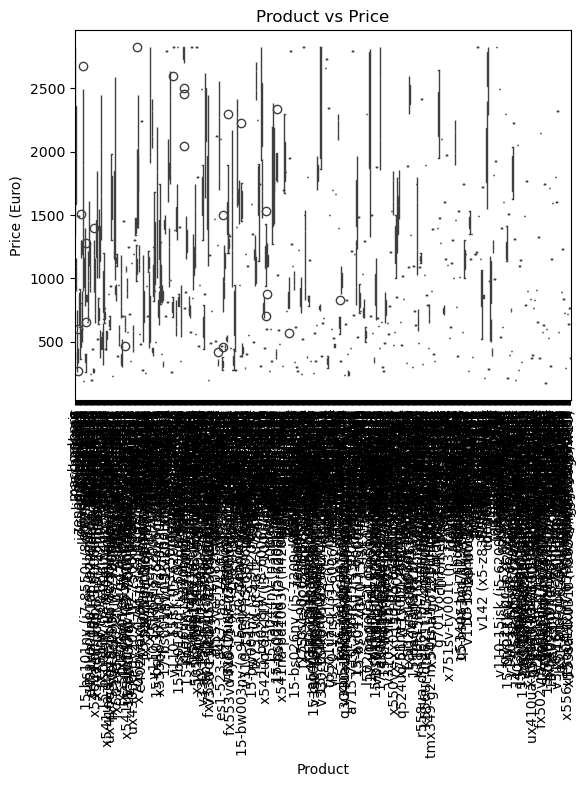

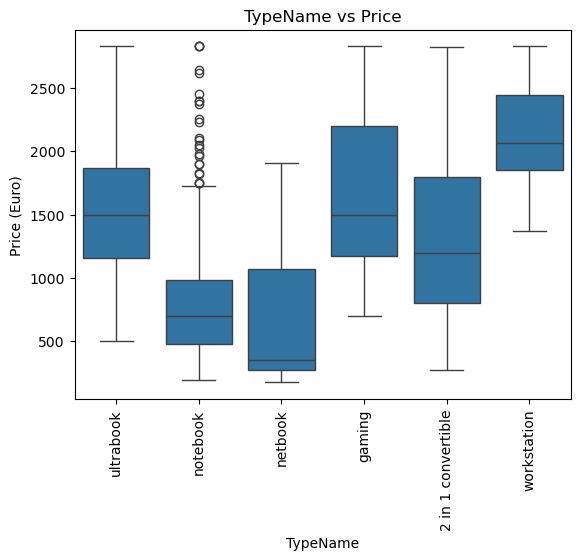

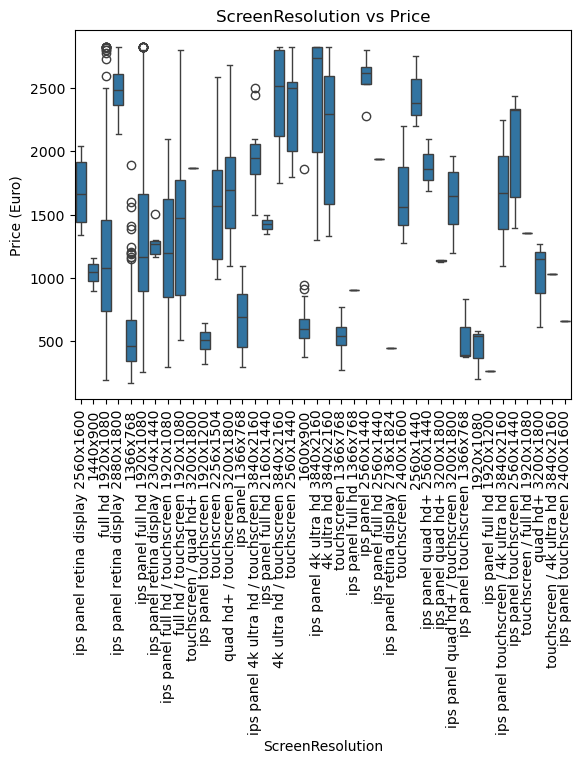

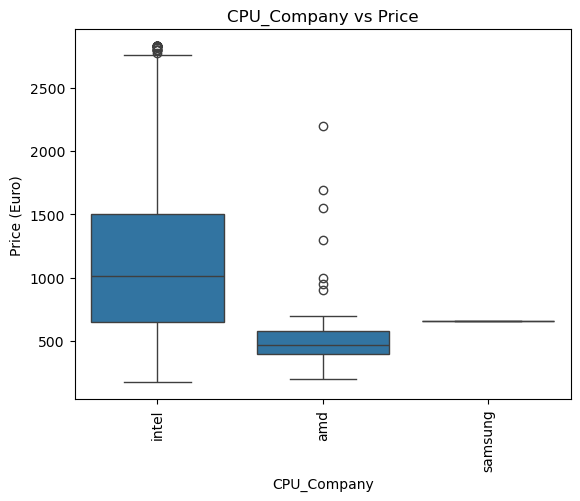

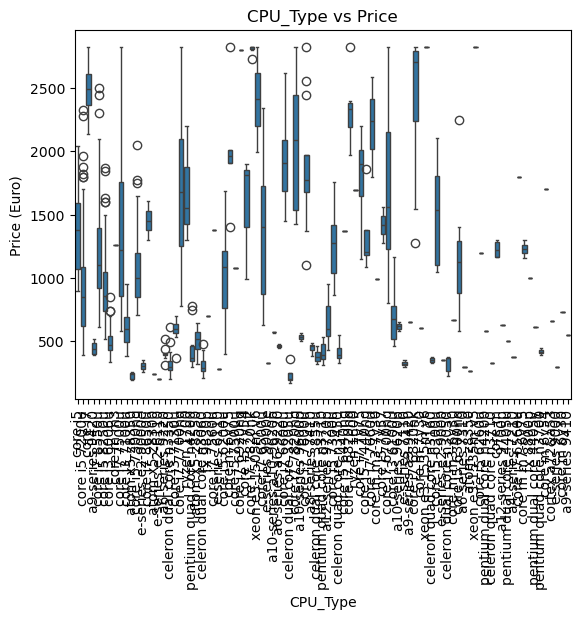

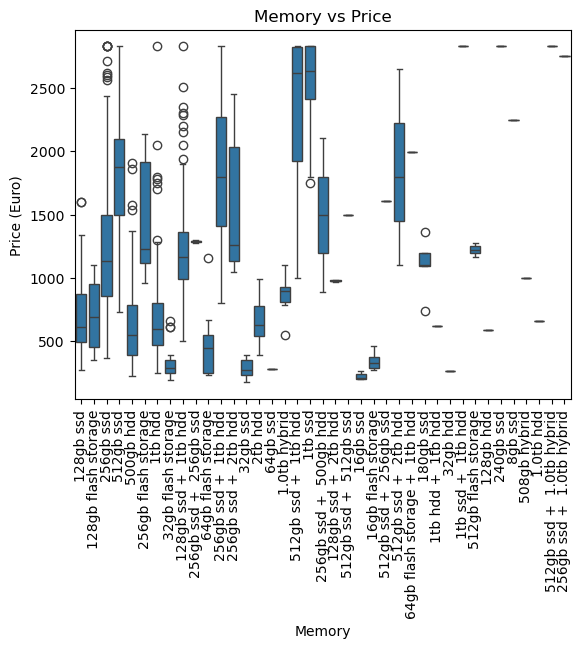

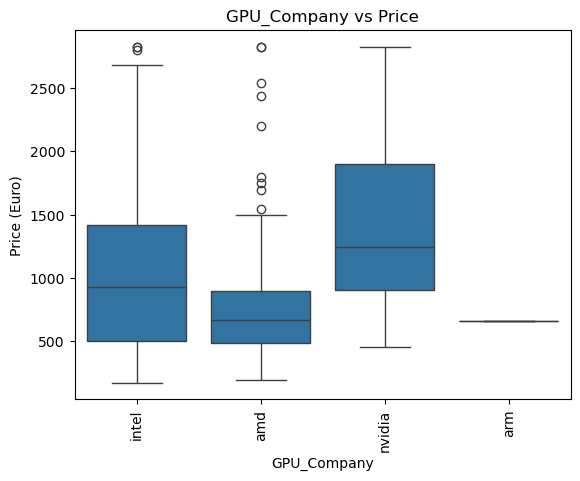

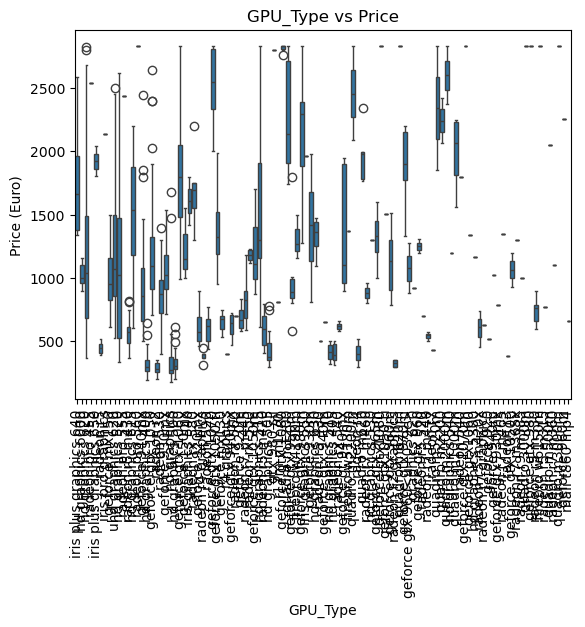

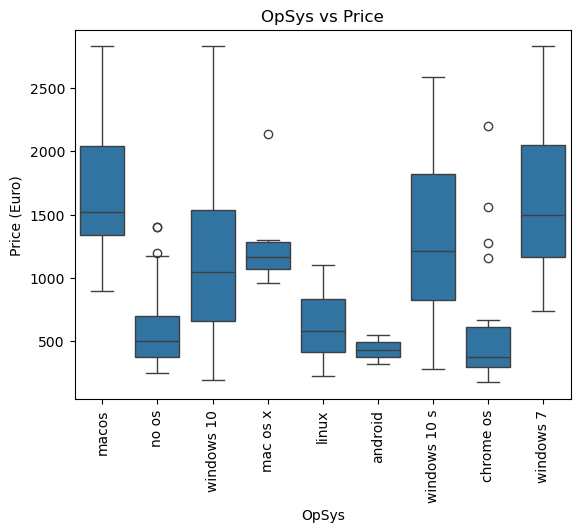

In [11]:
for col in num_cols:
    if col != "Price (Euro)":
        sns.scatterplot(x=df[col], y=df["Price (Euro)"])
        plt.title(f"{col} vs Price")
        plt.show()

for col in cat_cols:
    sns.boxplot(x=df[col], y=df["Price (Euro)"])
    plt.xticks(rotation=90)
    plt.title(f"{col} vs Price")
    plt.show()

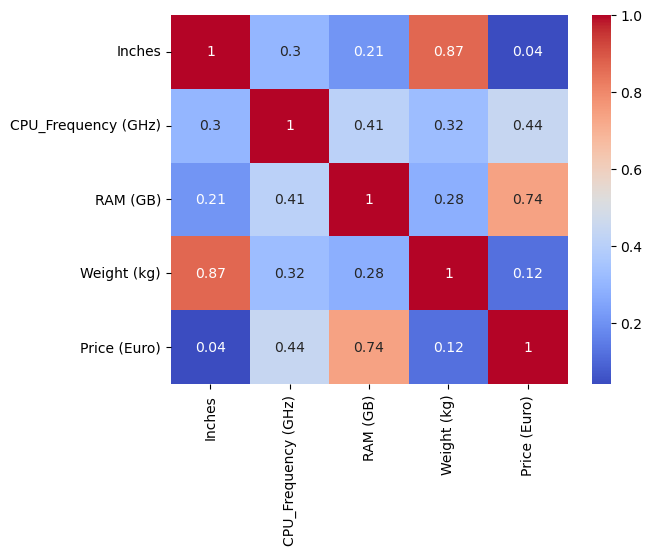

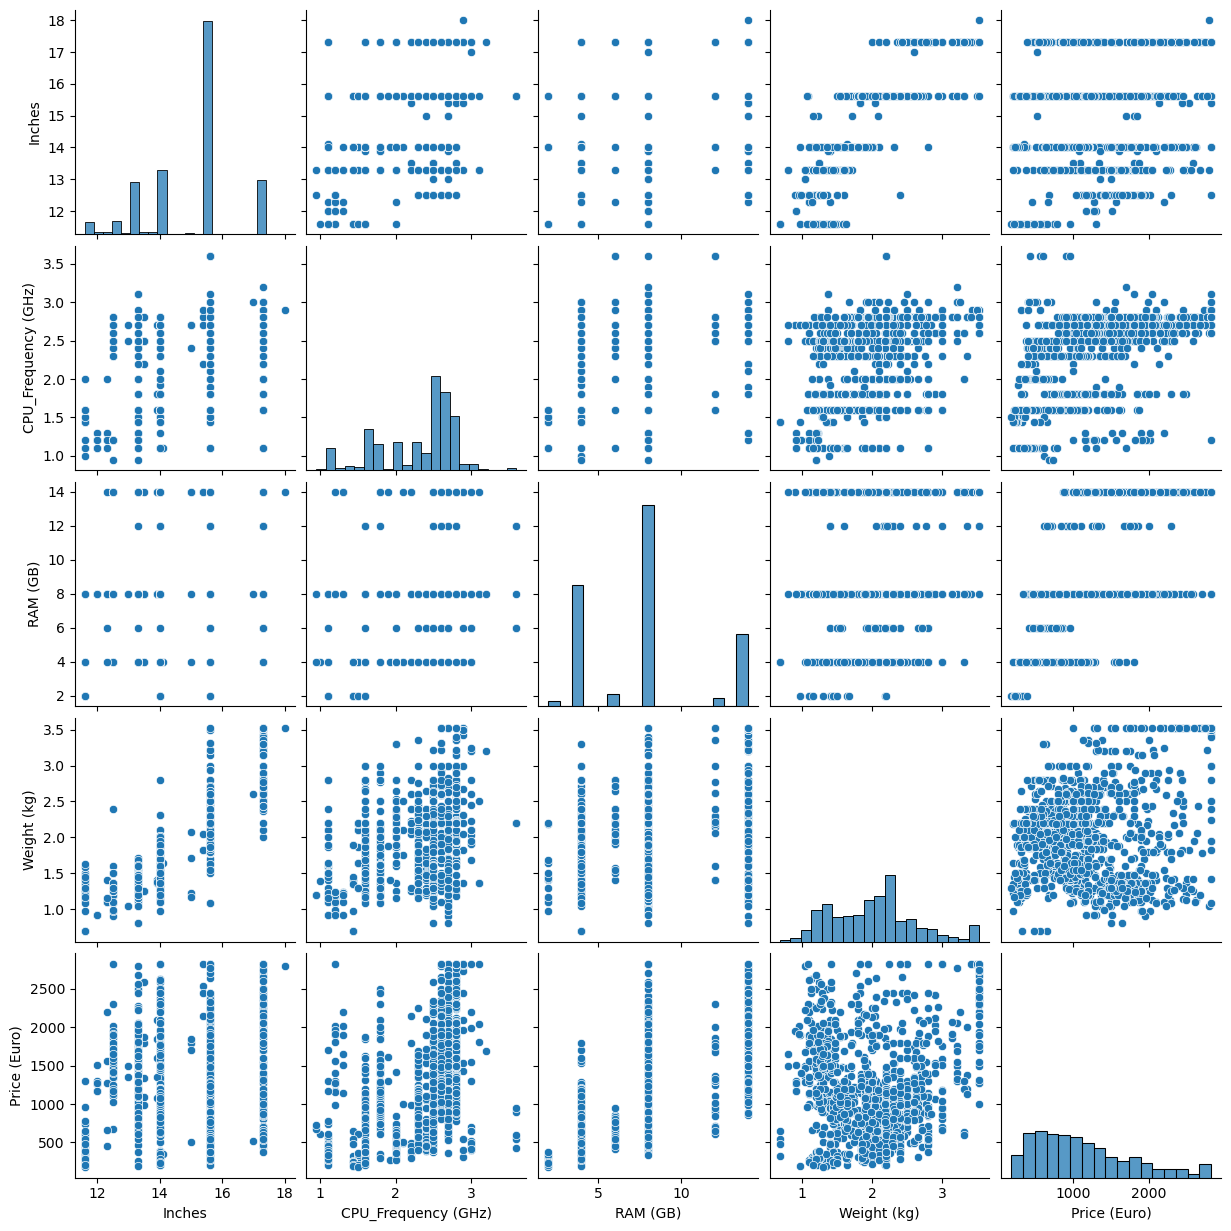

Company
razer        2391.142857
lg           2099.000000
msi          1728.908148
google       1677.666667
microsoft    1612.308333
apple        1562.758095
huawei       1424.000000
samsung      1413.444444
toshiba      1267.812500
dell         1187.831375
xiaomi       1133.462500
asus         1107.244211
lenovo       1082.560311
hp           1069.022127
fujitsu       729.000000
acer          633.464455
chuwi         314.296667
mediacom      295.000000
vero          217.425000
Name: Price (Euro), dtype: float64
Product
precision 7720                          2827.75
rog g701vo                              2827.75
precision 7520                          2827.75
thinkpad p70                            2827.75
thinkpad p71                            2827.75
                                         ...   
chromebook c910-c2st                     199.00
e402wa-ga010t (e2-6110/2gb/32gb/w10)     199.00
v131 (x5-z8350/4gb/32gb/fhd/w10)         196.00
vivobook e200ha                          1

In [12]:
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

sns.pairplot(df[num_cols])
plt.show()

for col in cat_cols:
    print(df.groupby(col)["Price (Euro)"].mean().sort_values(ascending=False))

In [13]:
df["SSD"] = df["Memory"].str.contains("ssd").astype(int)
df["HDD"] = df["Memory"].str.contains("hdd").astype(int)
df.drop("Memory", axis=1, inplace=True)

In [14]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),SSD,HDD
0,apple,macbook pro,ultrabook,13.3,ips panel retina display 2560x1600,intel,core i5,2.3,8.0,intel,iris plus graphics 640,macos,1.37,1339.69,1,0
1,apple,macbook air,ultrabook,13.3,1440x900,intel,core i5,1.8,8.0,intel,hd graphics 6000,macos,1.34,898.94,0,0
2,hp,250 g6,notebook,15.6,full hd 1920x1080,intel,core i5 7200u,2.5,8.0,intel,hd graphics 620,no os,1.86,575.00,1,0
3,apple,macbook pro,ultrabook,15.4,ips panel retina display 2880x1800,intel,core i7,2.7,14.0,amd,radeon pro 455,macos,1.83,2537.45,1,0
4,apple,macbook pro,ultrabook,13.3,ips panel retina display 2560x1600,intel,core i5,3.1,8.0,intel,iris plus graphics 650,macos,1.37,1803.60,1,0


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop("Price (Euro)", axis=1)
y = df["Price (Euro)"]

X = pd.get_dummies(X, drop_first=True,dtype=int)

scaler = StandardScaler()
X[num_cols.drop("Price (Euro)")] = scaler.fit_transform(X[num_cols.drop("Price (Euro)")])

In [16]:
X.head()

,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),SSD,HDD,Company_apple,Company_asus,Company_chuwi,Company_dell,...,GPU_Type_radeon rx 580,GPU_Type_uhd graphics 620,OpSys_chrome os,OpSys_linux,OpSys_mac os x,OpSys_macos,OpSys_no os,OpSys_windows 10,OpSys_windows 10 s,OpSys_windows 7
0,-1.221911,-0.006076,0.050587,-1.085809,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,-1.221911,-0.999256,0.050587,-1.136229,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0.404918,0.391196,0.050587,-0.262293,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0.263455,0.788468,1.809631,-0.312712,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,-1.221911,1.583012,0.050587,-1.085809,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error,accuracy_score

models = {
    "Linear": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, "R2:", r2_score(y_test, pred), "RMSE:", np.sqrt(mean_squared_error(y_test, pred)))


Linear R2: 0.7804846288621891 RMSE: 292.0099664027773
Decision Tree R2: 0.7796007698658242 RMSE: 292.5972518317423
Random Forest R2: 0.8664258702447847 RMSE: 227.7856614831572
Gradient Boosting R2: 0.8393060653444757 RMSE: 249.84171280693408


In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid, cv=5, scoring="r2")

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [20]:
preds = best_model.predict(X_test)

In [21]:
print("Best Model R2:", r2_score(y_test, preds))
print("Best Model RMSE:", np.sqrt(mean_squared_error(y_test, preds)))

Best Model R2: 0.8652744193146029
Best Model RMSE: 228.7653466695184
